In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import os



In [2]:
raw_data = scipy.io.loadmat('../data/raw_file.mat')
nino34_mat = scipy.io.loadmat('../data/nino34_mat.mat')

In [3]:
raw_data = raw_data['rawdata']

In [6]:
nino34_data = nino34_mat["nino34_data"]

In [7]:
import torch
raw_data_grid = torch.tensor(raw_data).view(-1, 180, 45)

In [8]:
raw_data_grid.shape

torch.Size([900, 180, 45])

In [16]:
nino34_data[0][0]["region_data"].shape

(900, 180, 45)

In [21]:
indsst = scipy.io.loadmat('../data/indsst.mat')

In [24]:
indsst = indsst['indsst']

In [26]:
raw_data_region.shape

torch.Size([900, 156])

In [20]:
raw_data_grid.min()

tensor(-8.4382, dtype=torch.float64)

In [19]:
nino34_data[0][0]["region_data"].min()

np.float64(-2.864633127848307)

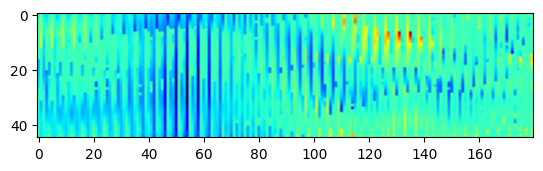

In [15]:
ims = plt.imshow(first_gird.T, cmap='jet')

In [18]:
# find number of zeros in the first grid
zeros_count = (first_gird == 0).sum()
print(f"Number of zeros in the first grid: {zeros_count}")

# find the indices of the zeros
zeros_indices = np.argwhere(first_gird == 0)

Number of zeros in the first grid: 2654


In [28]:
first_gird.mean()

tensor(-0.2095, dtype=torch.float64)

In [22]:
mask = first_gird != 0 
sea_coords = torch.nonzero(mask, as_tuple=False)

In [29]:
first_gird[sea_coords].mean()

tensor(-0.2833, dtype=torch.float64)

In [24]:
import networkx as nx

G = nx.Graph()
rows, cols = mask.shape

for coord in sea_coords:
    x, y = coord.tolist()
    G.add_node((x, y))  # add node

    # Possible 4 neighbors: left, right, up, down (no diagonals)
    neighbors = [
        ((x - 1) % rows, y),  # up
        ((x + 1) % rows, y),  # down
        (x, (y - 1) % cols),  # left (wrap around)
        (x, (y + 1) % cols),  # right (wrap around)
    ]

    for nx_, ny_ in neighbors:
        if mask[nx_, ny_]:
            G.add_edge((x, y), (nx_, ny_))

In [25]:
for x, y in G.nodes:
    G.nodes[(x, y)]['time_series'] = raw_data_grid[:, x, y]
    G.nodes[(x, y)]['coord'] = (x, y)

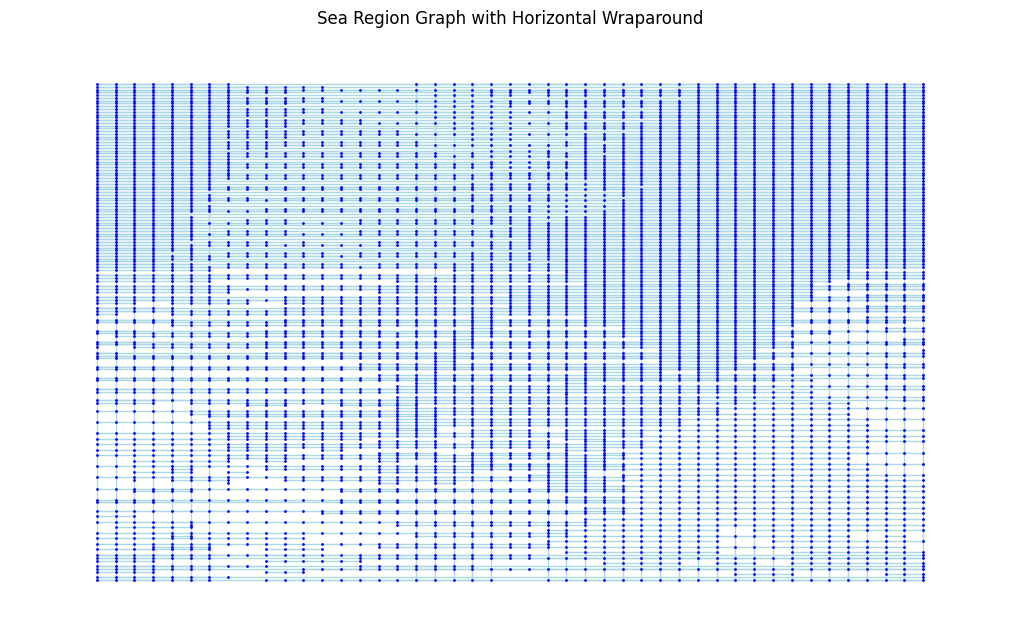

In [27]:
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Assume data is a torch tensor of shape (900, 180, 45)
data = raw_data_grid  # load your tensor here

mask = data[0] != 0  # shape (180, 45)
sea_coords = torch.nonzero(mask, as_tuple=False)

G = nx.Graph()
rows, cols = mask.shape

for coord in sea_coords:
    x, y = coord.tolist()
    G.add_node((x, y), pos=(y, -x))  # Use (y, -x) for better plotting (column as x-axis)

    neighbors = [
        ((x - 1) % rows, y),  # up
        ((x + 1) % rows, y),  # down
        (x, (y - 1) % cols),  # left (wrap)
        (x, (y + 1) % cols),  # right (wrap)
    ]

    for nx_, ny_ in neighbors:
        if mask[nx_, ny_]:
            G.add_edge((x, y), (nx_, ny_))

# Plotting
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(10, 6))
nx.draw(G, pos, node_size=1, edge_color='lightblue', node_color='blue', with_labels=False)
plt.title("Sea Region Graph with Horizontal Wraparound")
plt.axis('off')
plt.show()


In [30]:
mask.shape

NameError: name 'mask' is not defined

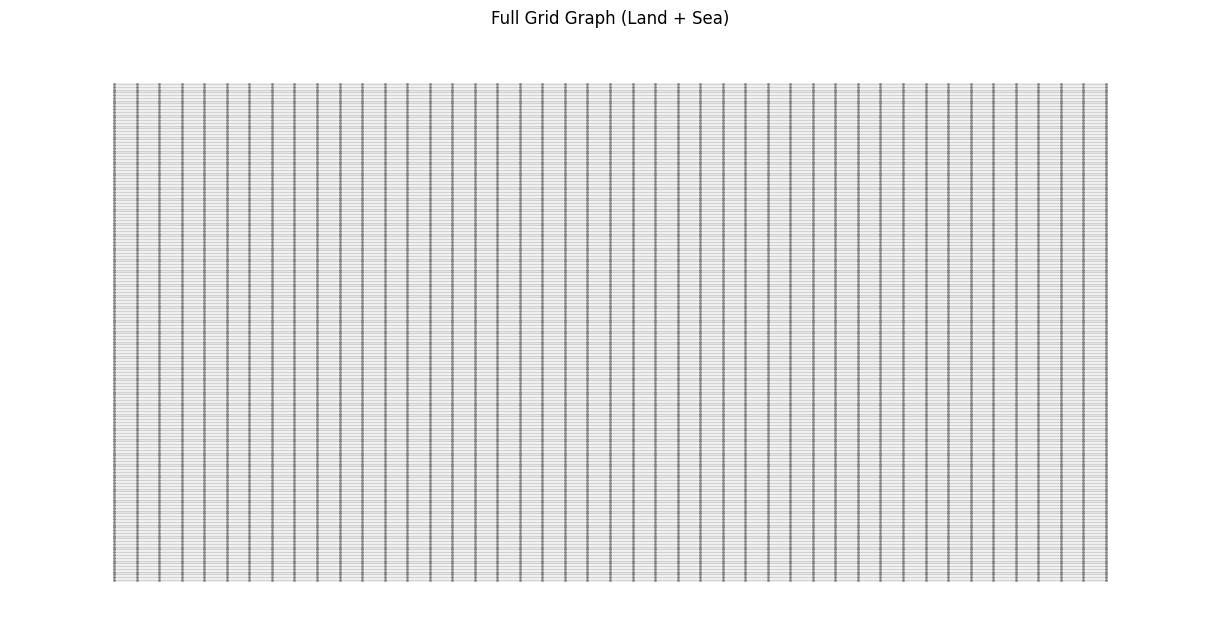

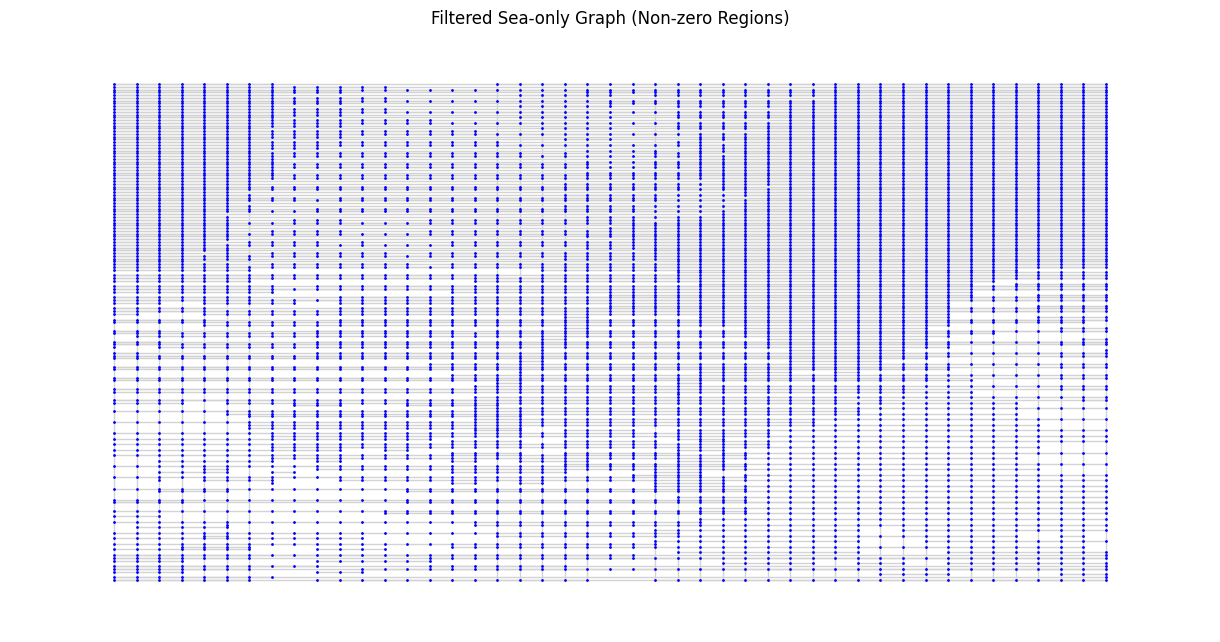

In [31]:
import torch
import networkx as nx
import matplotlib.pyplot as plt

# === Load data (assuming shape (900, 180, 45)) ===
data = raw_data_grid  # Your tensor here

# === Setup ===
mask = data[0] != 0  # Sea mask
rows, cols = mask.shape

# === Full Grid Graph (all nodes, no filtering) ===
G_full = nx.Graph()

for x in range(rows):
    for y in range(cols):
        G_full.add_node((x, y), pos=(y, -x))  # use (y, -x) for display

        neighbors = [
            ((x - 1) % rows, y),
            ((x + 1) % rows, y),
            (x, (y - 1) % cols),
            (x, (y + 1) % cols),
        ]

        for nx_, ny_ in neighbors:
            G_full.add_edge((x, y), (nx_, ny_))

# === Sea-only Graph (filtered, masked) ===
G_sea = nx.Graph()
sea_coords = torch.nonzero(mask, as_tuple=False)

for coord in sea_coords:
    x, y = coord.tolist()
    G_sea.add_node((x, y), pos=(y, -x))

    neighbors = [
        ((x - 1) % rows, y),
        ((x + 1) % rows, y),
        (x, (y - 1) % cols),
        (x, (y + 1) % cols),
    ]

    for nx_, ny_ in neighbors:
        if mask[nx_, ny_]:
            G_sea.add_edge((x, y), (nx_, ny_))

# === Plotting Function ===
def plot_graph(G, title, node_color='blue'):
    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(12, 6))
    nx.draw(G, pos, node_size=1, edge_color='lightgray', node_color=node_color, with_labels=False)
    plt.title(title)
    plt.axis('off')
    plt.show()

# === Plot both ===
plot_graph(G_full, "Full Grid Graph (Land + Sea)", node_color='gray')
plot_graph(G_sea, "Filtered Sea-only Graph (Non-zero Regions)", node_color='blue')


In [33]:
mask.shape

torch.Size([180, 45])